In [5]:
import json
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import os
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

# For embeddings and similarity computation
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    print("Required libraries imported successfully!")
except ImportError as e:
    print(f"Missing library: {e}")
    print("Please install with: pip install sentence-transformers scikit-learn networkx")

np.random.seed(42)

Required libraries imported successfully!


In [6]:
from scipy.sparse import find, csr_matrix
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import norm
from IPython.core.display import HTML

# des options permettent de limiter (ou non) le nombre de lignes/colonnes affichées
# par exemple :
# pd.set_option('display.max_rows', None)

# cette fonction permet d'afficher une "jolie" représentation du vecteur v
# ARGS :
#   v : le vecteur à afficher (par ex. une ligne de la matrice X)
#   features : le vocabulaire
#   top_n : le nombre de mots maximum à afficher
def print_feats(v, features, top_n = 30):
    _, ids, values = find(v)
    feats = [(ids[i], values[i], features[ids[i]]) for i in range(len(list(ids)))]
    top_feats = sorted(feats, key=lambda x: x[1], reverse=True)[0:top_n]
    return pd.DataFrame({"word" : [t[2] for t in top_feats], "value": [t[1] for t in top_feats]})   

# fonction qui permet d'afficher plusieurs tables pandas côte à côte (c'est cadeau)
def display_side_by_side(dfs:list, captions:list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += "&emsp;"
        #output += "\xa0\xa0\xa0"
    display(HTML(output))

# 1. Chargement et prise en main des données

In [35]:
def load_corpus(file_path: str) -> Dict[str, Dict]:
    """
    Load corpus data from a JSONL file.
    Returns a dictionary mapping document IDs to their associated metadata.
    """
    corpus = {}
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():  # skip empty lines
                doc = json.loads(line)
                doc_id = doc.get("_id")
                if doc_id is not None:
                    corpus[doc_id] = doc
                    
    return corpus


def load_queries(file_path: str) -> Dict[str, Dict]:
    """
    Load query data from a JSONL file.
    Returns a dictionary mapping query IDs to query metadata.
    """
    queries = {}
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                q = json.loads(line)
                q_id = q.get("_id")
                if q_id is not None:
                    queries[q_id] = q
                    
    return queries


def load_qrels(file_path: str) -> Dict[str, Dict[str, int]]:
    """
    Load relevance judgments from a TSV file.
    Returns a dictionary:
        { query_id : { candidate_id : relevance_score } }
    """
    qrels = {}
    
    with open(file_path, "r", encoding="utf-8") as f:
        next(f) #On saute l'en-tête
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) != 3:
                continue  
            
            q_id, c_id, score = parts
            score = int(score)

            if q_id not in qrels:
                qrels[q_id] = {}
            qrels[q_id][c_id] = score
    
    return qrels

# Load the dataset
print("Loading dataset...")
corpus = load_corpus('dataset_BE2/corpus.jsonl')
queries = load_queries('dataset_BE2/queries.jsonl')
qrels_valid = load_qrels('dataset_BE2/valid.tsv')


print(f"Loaded {len(corpus)} documents in corpus")
print(f"Loaded {len(queries)} queries")
print(f"Loaded relevance for {len(qrels_valid)} queries (dataset)")

Loading dataset...
Loaded 25657 documents in corpus
Loaded 1000 queries
Loaded relevance for 700 queries (dataset)


# 2 - Exploration des données et premier encodage

In [8]:
nb_docs = len(corpus)
nb_queries = len(queries)
nb_pairs = sum(len(docs) for docs in qrels_valid.values()) #on prend chaque dictionnaire de documents pour chaque requête et on somme
proportions = []
for qid, docs in qrels_valid.items(): ##[..].items contient une ligne par requête avec id de chaque document et score
    total_docs = len(docs)
    if total_docs == 0:
        continue  
    num_positifs = sum(1 for score in docs.values() if score == 1)
    proportion = num_positifs / total_docs
    proportions.append(proportion)

moyenne_proportion = sum(proportions) / len(proportions)

print(f"Taille du corpus : {nb_docs} documents")
print(f"Nombre de requêtes : {nb_queries}")
print(f"Nombre total de paires requête/document : {nb_pairs}")
print(f"Proportion d'articles pertinents par requète : {round(moyenne_proportion*100)}%")


Taille du corpus : 25657 documents
Nombre de requêtes : 1000
Nombre total de paires requête/document : 20950
Proportion d'articles pertinents par requète : 16%


In [ ]:
# Recherche des requêtes présentes dans le corpus

nb_queries_in_corpus = 0
nb_queries_not_in_corpus = 0

for q_id, query in queries.items():
    query_text = query["text"]
    query_text_lower = query_text.lower()

    found = False

    for id_doc, doc in corpus.items():
        doc_text = doc.get("text", "")
        
        if isinstance(doc_text, str) and query_text_lower in doc_text.lower():
            found = True
            break  #on arrête dès qu'un match est trouvé
        
    if found:
        nb_queries_in_corpus += 1
    else:
        nb_queries_not_in_corpus += 1

print(f"Nombre de requêtes dans le corpus : {nb_queries_in_corpus}")
print(f"Nombre de requêtes sans correspondance dans le corpus : {nb_queries_not_in_corpus}")


Nombre de requêtes correspondant à un titre du corpus : 4
Nombre de requêtes sans correspondance dans le corpus : 996


In [10]:
def show_example_query(corpus, queries, qrels, q_id=None):

    if q_id is None:
        q_id = next(iter(queries))  # prend la première requete

    query = queries[q_id]

    print("Requête")
    print("ID :", q_id)
    print("Titre :", query.get("text"))
    print()

    # On sépare les positifs des négatifs
    candidates = qrels[q_id]
    positives = [c for c, s in candidates.items() if s == 1]
    negatives = [c for c, s in candidates.items() if s == 0]

    # On affiche des candidats
    print("Candidats positifs")
    for c_id in positives[:3]:
        print("-", corpus[c_id]["title"])
    print()

    print("Candidats négatifs")
    for c_id in negatives[:3]:
        print("-", corpus[c_id]["title"])

show_example_query(corpus, queries, qrels_valid)


Requête
ID : 78495383450e02c5fe817e408726134b3084905d
Titre : A Direct Search Method to solve Economic Dispatch Problem with Valve-Point Effect

Candidats positifs
- A Hybrid EP and SQP for Dynamic Economic Dispatch with Nonsmooth Fuel Cost Function
- A modified particle swarm optimizer
- Identification and control of dynamic systems using recurrent fuzzy neural networks

Candidats négatifs
- A data mining approach for location prediction in mobile environments
- Treatment-Response Models for Counterfactual Reasoning with Continuous-time, Continuous-valued Interventions
- Dissecting and Reassembling Color Correction Algorithms for Image Stitching


### Premier encodage des données

In [11]:
def extract_titles(corpus, queries):
    #Retourne une liste des titres du corpus + queries ainsi que les IDs correspondants
    texts=[]
    ids=[]

    #corpus
    for doc_id, doc in corpus.items():
        title = doc.get("title", "").strip()
        texts.append(title)
        ids.append(doc_id)
    
    #requêtes
    for q_id, query in queries.items():
        title=query.get("text")
        texts.append(title.strip())
        ids.append(q_id)

    return texts, ids

from sklearn.feature_extraction.text import CountVectorizer

def build_document_term_matrix(texts):
    #vectorizer= CountVectorizer(max_features=5000, stop_words='english', min_df=2, max_df=0.8)
    vectorizer= TfidfVectorizer(max_features=5000, stop_words='english', min_df=2, max_df=0.8) 
    # Taille maximale du vocabulaire = max_features
    # suppression des mots-outils de la langue anglaise
    # suppression des mots trop rares (apparaissant dans un seul article) ou trop fréquents (apparaissant dans 80% des articles ou plus)
    # stemming ?
    # Pondération par TF-IDF : donne plus d'importance aux mots discriminants et réduit l’influence des mots fréquents
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

texts, ids = extract_titles(corpus, queries)
X, vectorizer = build_document_term_matrix(texts)

print(X.shape)
print("Longueur du vocabulaire :", len(vectorizer.get_feature_names_out()))

# Exemple : affichage des 3 termes les plus fréquents du 3è document (dans son titre)
features = vectorizer.get_feature_names_out()
example_vec=X[2]
display(print_feats(example_vec,features, top_n=3))

(26657, 5000)
Longueur du vocabulaire : 5000


,word,value
0,fuzzy,0.598473
1,bases,0.381727
2,tuning,0.364401


### Distribution des mots les plus fréquemment employés dans le corpus

,word,value
0,based,511.738909
1,using,485.756967
2,learning,470.430844
3,data,353.416084
4,networks,343.130528
5,analysis,316.094841
6,detection,311.993531
7,neural,287.721266
8,deep,252.926585
9,recognition,236.916577


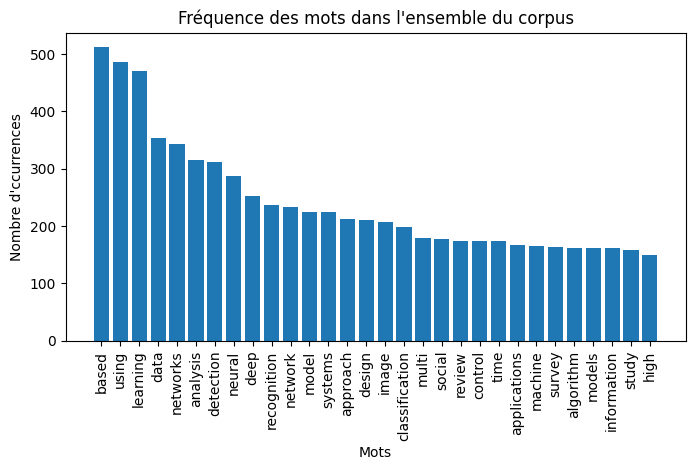

In [12]:
from scipy.sparse import csr_matrix

term_frequencies = np.asarray(X.sum(axis=0)).ravel()
freq_vector = csr_matrix(term_frequencies)
features = vectorizer.get_feature_names_out()

#Affichage des 30 mots les plus fréquents
top_words=print_feats(freq_vector,features, top_n=30)
display(top_words)

#Affichage graphique
plt.figure(figsize=(8,4))
plt.bar(top_words["word"], top_words["value"])
plt.xticks(rotation=90)
plt.xlabel("Mots")
plt.ylabel("Nombre d'ccurrences")
plt.title("Fréquence des mots dans l'ensemble du corpus")
plt.show()

# 3. Comparaison de documents et premier moteur de recherche

### Comparaison de documents

D'abord, sans prise en compte des résumés, seulement des titres.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def compare_docs(i,j,X,ids,corpus):
    v1=X[i]
    v2=X[j]
    sim = cosine_similarity(v1,v2)[0,0]

    print(f"Cosine similarity entre {ids[i]} et {ids[j]} : {sim:.4f}\n")
    print("Doc1 : ", corpus.get(ids[i], {}).get("title", ""))
    print("Doc2 : ", corpus.get(ids[j], {}).get("title", ""))

    #Affichage des mots en commun :
    common = v1.multiply(v2)
    display(print_feats(common,features, top_n=20))

compare_docs(10, 7, X, ids, corpus)

Cosine similarity entre 9f234867df1f335a76ea07933e4ae1bd34eeb48a et 1ae0ac5e13134df7a0d670fc08c2b404f1e3803c : 0.1044

Doc1 :  Automatic Machine Translation Evaluation: A Qualitative Approach
Doc2 :  A data mining approach for location prediction in mobile environments


,word,value
0,approach,0.104424


En ne prenant en compte que les titres, il est logiquement difficile de trouver des similarités entre 2 documents différents. 

In [14]:
def extract_title_and_text(corpus):
    texts=[]
    ids=[]
    for doc_id, doc in corpus.items():
        txt=(doc.get("title","") + " " + doc.get("text","")).strip()
        texts.append(txt)
        ids.append(doc_id)
    return texts, ids

texts_full, ids_full = extract_title_and_text(corpus)
X_full, vectorizer_full = build_document_term_matrix(texts_full)

Premier moteur de recherche, qui prend un ensemble de mots clefs, calcule un score pour chaque document de la base et retourne les 10 premieres résultats.

In [15]:
def search_engine(query_text, vectorizer, X, ids, corpus, top_k=10):
    # On encode la requête avec le même vectorizer
    q_vec=vectorizer.transform([query_text])

    similarities = cosine_similarity(q_vec, X)[0]
    #On récupère les indices des documents triés par score décroissant
    top_idx = similarities.argsort()[::-1][:top_k]

    results= []
    print("Meilleurs résumtats pour la requête \"", query_text,"\" :\n")
    for idx in top_idx:
        doc_id = ids[idx]
        title = corpus[doc_id].get("title", "")
        score = similarities[idx]
        results.append((doc_id, title, score))

        print(f"[score={score:.4f}] {title}")

    return results

results = search_engine("graph neural networks for chemistry", vectorizer_full, X_full, ids_full, corpus, top_k=10)

Meilleurs résumtats pour la requête " graph neural networks for chemistry " :

[score=0.5453] Semi-Supervised Classification with Graph Convolutional Networks
[score=0.5159] Graph Embedding Problem Settings Graph Embedding Input Graph Embedding Output Homogeneous Graph Heterogeneous Graph Graph with Auxiliary Information Graph Constructed from Non-relational Data Node Embedding Edge Embedding Hybrid Embedding Whole-Graph Embedding Graph Embedding Techniques Matrix Facto
[score=0.5095] Neural Graph Machines: Learning Neural Networks Using Graphs
[score=0.4815] Graph construction and b-matching for semi-supervised learning
[score=0.4780] Graph2Seq: Scalable Learning Dynamics for Graphs
[score=0.4659] Computational Capabilities of Graph Neural Networks
[score=0.4656] Query Optimization Techniques In Graph Databases
[score=0.4540] G-SQL: Fast Query Processing via Graph Exploration
[score=0.4538] Designing Neural Networks Using Genetic Algorithms with Graph Generation System
[score=0.4457] 

Essayons quelques variantes, en : 
- Modifiant les paramètres du "vectoriseur" : taille du vocabulaire, suppression des mots-outils, suppression des mots trop rares ou trop fréquents, stemming (réduit les mots à leurs racines)
- Utilisant une autre pondération, comme TFxIDF

Toutes ces options ne permettent pas forcément d'augmenter les scores obtenus par search_engine, mais contribuent à rendre ces scores plus adéquats.

# 4. Utiliser un meilleur encodeur de documents

On cherche à utiliser un encodage spécialisé pour construire des représentations denses beaucoup plus adaptées à ces données. Pour cela, on suit 3 étapes : 
- Construction des embeddings
- Sauvegarde dans un fichier 
- Chargement des embeddings s'ils existent déjà

In [16]:
import os
import numpy as np
from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDINGS_FILE = "embeddings.npy"
TEXT_FILE = "corpus.npy"

def get_embeddings(texts):
    # Charge le fichier s'il existe déjà
    if os.path.exists(EMBEDDINGS_FILE):
        print("Chargement des embeddings")
        embeddings = np.load(EMBEDDINGS_FILE)
        return embeddings
    
    # SInon
    print("Calcul des embeddings")
    model = SentenceTransformer(MODEL_NAME)
    embeddings = model.encode(texts, show_progress_bar=False)
    print("Sauvegarde dans", EMBEDDINGS_FILE)
    np.save(EMBEDDINGS_FILE, embeddings)

    return embeddings

texts = [(doc.get("title","") + " " + doc.get("text","")).strip() for doc in corpus.values()]

embeddings = get_embeddings(texts)
print("taille des embeddings :", embeddings.shape)

Chargement des embeddings
taille des embeddings : (25657, 384)


Les embeddings contiennent les titres ainsi que les contenus des articles.

# 5. Nouveau moteur de recherche

A présent, l'objectif est double :

- Implémenter un moteur de recherche, mais cette fois en vous basant sur les représentations denses construites à l'étape précédente.
- Evaluer la pertinence de votre moteur grâce aux annotations fournies dans le fichier valid.tsv qui portent sur les requêtes de query.tsv : pour une requête donnée, votre système doit retourner préférentiellement les articles pertinents (score noté 1) en comparaison des articles non pertinents (score noté 0).

Commençons par implémenter le moteur de recherche proprement dit : à partir d'une requête, le système doit trier les 25 documents candidats fournis.

In [17]:
corpus_ids = list(corpus.keys()) #même ordre que pour l'encodage
id_to_index = {doc_id: i for i, doc_id in enumerate(corpus_ids)}

model = SentenceTransformer("all-MiniLM-L6-v2")

def encode_query(query):
    text = query.get("text", "")
    return model.encode([text])[0]  # vecteur 1 dimension

def search_with_embeddings(query, candidate_ids, embeddings, id_to_index):
    q_emb = encode_query(query).reshape(1,-1) #encode la requête
    cand_embs = np.array([embeddings[id_to_index[cid]] for cid in candidate_ids])
    sims = cosine_similarity(q_emb, cand_embs)[0] #shape = 25
    # Tri par ordre décroissant de scopre
    ranked_candidates = sorted(zip(candidate_ids, sims), key=lambda x: x[1], reverse=True)

    return ranked_candidates


On cherche maintenant à évaluer la pertinence du moteur en utilisant les annotations de valid.tsv.

In [18]:
#Test d'une requête :
valid_query_id = list(qrels_valid.keys())
query_id = valid_query_id[3]
query = queries[query_id]
candidate_ids = list(qrels_valid[query_id].keys())
ranked=search_with_embeddings(query, candidate_ids,embeddings, id_to_index)

# Affichage
print("Requête :", query["text"])
for doc_id, score in ranked[:10]:
    pertinence = qrels_valid[query_id].get(doc_id, 0)   #0 ou 1
    print(f"{score:.4f} - {corpus[doc_id]['title']} (pertinent = {pertinence})")



Requête : Extended object tracking using IMM approach for a real-world vehicle sensor fusion system
0.4823 - Bayesian Occupancy Filtering for Multitarget Tracking: An Automotive Application (pertinent = 1)
0.4625 - Object tracking with de-autocorrelation scheme for a dynamic occupancy gridmap system (pertinent = 1)
0.4556 - Fusion of laser and radar sensor data with a sequential Monte Carlo Bayesian occupancy filter (pertinent = 1)
0.4546 - Modeling and Tracking the Driving Environment With a Particle-Based Occupancy Grid (pertinent = 1)
0.3082 - The IHS Transformations Based Image Fusion (pertinent = 0)
0.2213 - Detecting unexpected obstacles for self-driving cars: Fusing deep learning and geometric modeling (pertinent = 0)
0.1885 - Designing a robotic assistant for healthcare applications (pertinent = 0)
0.1654 - A Novel Approach of an Absolute Encoder Coding Pattern (pertinent = 0)
0.1140 - A Proposal for Statistical Outlier Detection in Relational Structures (pertinent = 0)
0.1091 

A présent, faisons tourner le moteur de recherche sur l'ensemble des requêtes du fichier pour calculer des indicateurs de qualité.

- Precision : proportion de documents pertinents dans les 5 premiers
- Rappel : proportion de pertinents récupérés parmi tous les pertinents
- Score F1 : moyenne harmonique de la précision et du rappel
- AUC : capacité à classer les pertinents au-dessus des non-pertinents

In [19]:
"""
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

K=5

all_true_labels = []
all_pred_labels = []
all_pred_scores = []

for query_id in valid_query_id:
    query = queries[query_id]
    candidate_ids = list(qrels_valid[query_id].keys())

    #score du moteur
    ranked = search_with_embeddings(query, candidate_ids, embeddings, id_to_index)
    
    # Scores continus pour l'AUC
    pred_scores = [score for (_,score) in ranked]
    true_labels = [qrels_valid[query_id][doc_id] for (doc_id,_) in ranked]

    pred_labels = [1 if i<K else 0 for i in range(len(ranked))] # Seuls les K premiers articles prédits sans considérés positifs
    
    #Stockage global
    all_pred_scores.extend(pred_scores)
    all_pred_labels.extend(pred_labels)
    all_true_labels.extend(true_labels)

# Calcul des indicateurs de qualité
precision = precision_score(all_true_labels, all_pred_labels)
recall = recall_score(all_true_labels, all_pred_labels)
f1 = f1_score(all_true_labels, all_pred_labels)
auc = roc_auc_score(all_true_labels, all_pred_scores)

print(f"Précision : {precision:.4f}")
print(f"Rappel    : {recall:.4f}")
print(f"F-mesure  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")
"""


'\nfrom sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score\n\nK=5\n\nall_true_labels = []\nall_pred_labels = []\nall_pred_scores = []\n\nfor query_id in valid_query_id:\n    query = queries[query_id]\n    candidate_ids = list(qrels_valid[query_id].keys())\n\n    #score du moteur\n    ranked = search_with_embeddings(query, candidate_ids, embeddings, id_to_index)\n    \n    # Scores continus pour l\'AUC\n    pred_scores = [score for (_,score) in ranked]\n    true_labels = [qrels_valid[query_id][doc_id] for (doc_id,_) in ranked]\n\n    pred_labels = [1 if i<K else 0 for i in range(len(ranked))] # Seuls les K premiers articles prédits sans considérés positifs\n    \n    #Stockage global\n    all_pred_scores.extend(pred_scores)\n    all_pred_labels.extend(pred_labels)\n    all_true_labels.extend(true_labels)\n\n# Calcul des indicateurs de qualité\nprecision = precision_score(all_true_labels, all_pred_labels)\nrecall = recall_score(all_true_labels, all_pred_labels)

In [20]:
# Idem sous forme de fonctions : 

import numpy as np
import math
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def precision_at_k(labels, k):
    return np.mean(labels[:k])

def recall_at_k(labels, k):
    total = sum(labels)
    return 0 if total == 0 else sum(labels[:k]) / total

def average_precision(labels):
    cum_prec = 0
    hits = 0
    for i, lab in enumerate(labels):
        if lab == 1:
            hits += 1
            cum_prec += hits / (i + 1)
    return 0 if hits == 0 else cum_prec / hits

def reciprocal_rank(labels):
    for i, lab in enumerate(labels):
        if lab == 1:
            return 1 / (i + 1)
    return 0

def dcg_at_k(labels, k):
    return sum(lab / math.log2(i + 2) for i, lab in enumerate(labels[:k]))

def ndcg_at_k(labels, k):
    ideal = sorted(labels, reverse=True)
    ideal_dcg = dcg_at_k(ideal, k)
    return 0 if ideal_dcg == 0 else dcg_at_k(labels, k) / ideal_dcg


In [56]:
def evaluate_top_k(embeddings, K, queries, qrels, id_to_index):
    all_true = []
    all_pred = []
    all_scores = []

    for qid, query in queries.items():

        if qid not in qrels:
            continue

        candidates = list(qrels[qid].keys())
        ranked = search_with_embeddings(query, candidates, embeddings, id_to_index)

        scores = [s for (_, s) in ranked]
        labels = [qrels[qid][doc] for (doc, _) in ranked]

        all_scores.extend(scores)
        all_true.extend(labels)
        all_pred.extend([1 if i < K else 0 for i in range(len(ranked))])

    precision = precision_score(all_true, all_pred)
    recall = recall_score(all_true, all_pred)
    f1 = f1_score(all_true, all_pred)
    auc = roc_auc_score(all_true, all_scores)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }


Calcul d'autres types d'indicateurs :
- MAP : moyenne des précisions cumulatives → très bon indicateur de ranking
- MRR : si le premier document pertinent est bien placé
- nDCG : qualité du classement pondérée par la position

In [22]:
"""
import math

def precision_at_k(true_labels, k):
    return np.mean(true_labels[:k])

def recall_at_k(true_labels, k):
    total_positives = sum(true_labels)
    if total_positives == 0:
        return 0
    return sum(true_labels[:k]) / total_positives

def average_precision(true_labels):
    cum_precision = 0
    positive_count = 0
    
    for idx, label in enumerate(true_labels):
        if label == 1:
            positive_count += 1
            cum_precision += positive_count / (idx + 1)

    if positive_count == 0:
        return 0
    
    return cum_precision / positive_count

def reciprocal_rank(true_labels):
    for idx, label in enumerate(true_labels):
        if label == 1:
            return 1 / (idx + 1)
    return 0

def dcg_at_k(labels, k):
    return sum(label / math.log2(i + 2) for i, label in enumerate(labels[:k]))

def ndcg_at_k(true_labels, k):
    ideal = sorted(true_labels, reverse=True)
    ideal_dcg = dcg_at_k(ideal, k)
    if ideal_dcg == 0:
        return 0
    return dcg_at_k(true_labels, k) / ideal_dcg


K = 5  # top-K

all_AP = []
all_RR = []
all_nDCG_at_K = []

all_true_labels_auc = []
all_pred_scores_auc = []

for query_id in valid_query_id:
    query = queries[query_id]
    candidate_ids = list(qrels_valid[query_id].keys())
    
    ranked = search_with_embeddings(query, candidate_ids, embeddings, id_to_index)

    # Scores continus pour l'AUC
    pred_scores = [score for (_, score) in ranked]
    true_labels = [qrels_valid[query_id][doc_id] for (doc_id, _) in ranked]

    # Stockage AUC
    all_pred_scores_auc.extend(pred_scores)
    all_true_labels_auc.extend(true_labels)

    # Métriques ranking
    all_AP.append(average_precision(true_labels))
    all_RR.append(reciprocal_rank(true_labels))
    all_nDCG_at_K.append(ndcg_at_k(true_labels, K))

# AUC global
auc = roc_auc_score(all_true_labels_auc, all_pred_scores_auc)

# Moyennes finales
print(f"MAP           : {np.mean(all_AP):.4f}")
print(f"MRR           : {np.mean(all_RR):.4f}")
print(f"nDCG          : {np.mean(all_nDCG_at_K):.4f}")
print(f"AUC           : {auc:.4f}")
"""


'\nimport math\n\ndef precision_at_k(true_labels, k):\n    return np.mean(true_labels[:k])\n\ndef recall_at_k(true_labels, k):\n    total_positives = sum(true_labels)\n    if total_positives == 0:\n        return 0\n    return sum(true_labels[:k]) / total_positives\n\ndef average_precision(true_labels):\n    cum_precision = 0\n    positive_count = 0\n    \n    for idx, label in enumerate(true_labels):\n        if label == 1:\n            positive_count += 1\n            cum_precision += positive_count / (idx + 1)\n\n    if positive_count == 0:\n        return 0\n    \n    return cum_precision / positive_count\n\ndef reciprocal_rank(true_labels):\n    for idx, label in enumerate(true_labels):\n        if label == 1:\n            return 1 / (idx + 1)\n    return 0\n\ndef dcg_at_k(labels, k):\n    return sum(label / math.log2(i + 2) for i, label in enumerate(labels[:k]))\n\ndef ndcg_at_k(true_labels, k):\n    ideal = sorted(true_labels, reverse=True)\n    ideal_dcg = dcg_at_k(ideal, k)\n 

In [23]:
# Implémentation sous forme de fonction pour la suite

def evaluate_ranking(embeddings, K, queries, qrels, id_to_index):
    APs = []
    RRs = []
    nDCGs = []

    all_scores = []
    all_true = []

    for qid, query in queries.items():

        if qid not in qrels:
            continue

        candidates = list(qrels[qid].keys())
        ranked = search_with_embeddings(query, candidates, embeddings, id_to_index)

        scores = [s for (_, s) in ranked]
        labels = [qrels[qid][doc] for (doc, _) in ranked]

        all_scores.extend(scores)
        all_true.extend(labels)

        APs.append(average_precision(labels))
        RRs.append(reciprocal_rank(labels))
        nDCGs.append(ndcg_at_k(labels, K))

    return {
        "MAP": np.mean(APs),
        "MRR": np.mean(RRs),
        "nDCG": np.mean(nDCGs),
    }


In [24]:
def evaluate_all(embeddings, K, queries, qrels, id_to_index):
    results = {}

    results["top_K_metrics"] = evaluate_top_k(
        embeddings, K, queries, qrels, id_to_index
    )

    results["ranking_metrics"] = evaluate_ranking(
        embeddings, K, queries, qrels, id_to_index
    )

    return results

K = 5

metrics = evaluate_all(
    embeddings,
    K,
    queries,
    qrels_valid,
    id_to_index
)

print(metrics)


{'top_K_metrics': {'precision': 0.8031428571428572, 'recall': 0.8147826086956522, 'f1': 0.8089208633093525, 'auc': 0.9550363064182197}, 'ranking_metrics': {'MAP': 0.885545841873099, 'MRR': 0.9747755102040816, 'nDCG': 0.853417170119763}}


# 6. Intermède : exploration avec des modèles thématiques

On cherche dans cette partie à explorer des thématiques latentes dans le corpus, en suivant l'exemple d'utilisation de l'algorithme LDA dans le cours.
 
Cet algorithme permet de chercher les thèmes récurrents du corpus, et de savoir quels documents parlent de quel thème.

In [25]:
# Préparation du corpus :
corpus[doc_id]["title"]
corpus[doc_id]["text"]

documents = [
    corpus[doc_id]["title"] + " " + corpus[doc_id]["text"]
    for doc_id in corpus
]

# Tokenisation et nettoyage :
from gensim.utils import simple_preprocess

def sent_to_words(sentences):
    for sentence in sentences:
        yield simple_preprocess(str(sentence), deacc=True)

data_words = list(sent_to_words(documents))
print("Nombre de documents :", len(data_words))

# On retire les stopwords comme précédemment
with open("Stop-words-en.txt") as f:
    stopwords = [line.strip() for line in f.readlines()]

def remove_stopwords(texts):
    return [[word for word in doc if word not in stopwords] for doc in texts]

data_words_nostops = remove_stopwords(data_words)

# Construction du dictionnaire

from gensim import corpora

dico = corpora.Dictionary(data_words_nostops)
dico.filter_extremes(no_below=10)  # filtrer les mots rares
bow_corpus = [dico.doc2bow(text) for text in data_words_nostops]

Nombre de documents : 25657


Entraînement LDA :

In [26]:
from gensim.models.ldamodel import LdaModel
import logging
import os

ntopics = 20         # par exemple
generate_lda = False # Mettre True pour éxecuter le LDA et créer le document models, False pour charger les fichiers déjà créés

model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

model_path = f"models/lda_model_{ntopics}"

if generate_lda:
    print("Pas loaded")
    pass
    logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)
    ldamodel = LdaModel(
        bow_corpus,
        num_topics=ntopics,
        id2word=dico,
        passes=50,
        random_state=100
    )
    ldamodel.save(model_path)
else:
    ldamodel = LdaModel.load(model_path)

topics = ldamodel.show_topics(num_topics=ntopics, formatted=False)
topics
for i, words in topics:
    print("Topic", i, ":", [w for w,_ in words])


Topic 0 : ['security', 'can', 'code', 'attacks', 'privacy', 'attack', 'based', 'system', 'information', 'used']
Topic 1 : ['data', 'mining', 'online', 'information', 'analysis', 'model', 'time', 'can', 'users', 'prediction']
Topic 2 : ['can', 'one', 'will', 'game', 'theory', 'games', 'systems', 'agent', 'behavior', 'may']
Topic 3 : ['network', 'networks', 'graph', 'traffic', 'wireless', 'nodes', 'detection', 'communication', 'graphs', 'social']
Topic 4 : ['classification', 'data', 'features', 'detection', 'feature', 'learning', 'based', 'methods', 'method', 'performance']
Topic 5 : ['control', 'system', 'robot', 'sensor', 'vehicle', 'based', 'paper', 'using', 'model', 'autonomous']
Topic 6 : ['data', 'performance', 'systems', 'cloud', 'computing', 'system', 'applications', 'distributed', 'time', 'large']
Topic 7 : ['brain', 'cognitive', 'music', 'memory', 'activity', 'emotion', 'functional', 'human', 'emotional', 'cortex']
Topic 8 : ['software', 'process', 'design', 'paper', 'developme

Visualisation :

In [27]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

lda_viz = gensimvis.prepare(
    ldamodel,
    bow_corpus,
    dictionary=dico
)
lda_viz


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
19    -0.062466 -0.058247       1        1  8.570252
4     -0.051434 -0.113088       2        1  8.422137
12     0.226645  0.009770       3        1  7.554968
13     0.044308 -0.144610       4        1  7.090763
6     -0.032538 -0.092007       5        1  6.459787
10     0.108743  0.196729       6        1  6.025770
17    -0.100820 -0.044443       7        1  5.514944
8      0.041686 -0.089564       8        1  5.320354
1      0.142158 -0.072230       9        1  5.120516
2      0.124034 -0.045605      10        1  4.982921
9     -0.025592 -0.120668      11        1  4.629717
16     0.064374 -0.061381      12        1  4.352911
0      0.002496 -0.102940      13        1  4.162590
14    -0.196017  0.092844      14        1  3.987841
15    -0.184938  0.106406      15        1  3.629172
5     -0.164304  0.011409      16        1  3.610059
11    -0.209047  0.154842      17        1  3.375094
7      0.169836  0.228421      18        1  2.811614
18     0.107449  0.184215      19        1  2.404688
3     -0.004573 -0.039853      20        1  1.973902, topic_info=           Term          Freq         Total Category  logprob  loglift
238        data  19935.000000  19935.000000  Default  30.0000  30.0000
39     learning  10879.000000  10879.000000  Default  29.0000  29.0000
43      network   7865.000000   7865.000000  Default  28.0000  28.0000
44     networks   5989.000000   5989.000000  Default  27.0000  27.0000
836       image   6091.000000   6091.000000  Default  26.0000  26.0000
...         ...           ...           ...      ...      ...      ...
1972     social    637.277695   4609.915717  Topic20  -4.4335   1.9464
5         based    502.249171  18229.076034  Topic20  -4.6716   0.3335
537          de    277.673585    579.223437  Topic20  -5.2642   3.1899
1307  community    285.690643   1030.532132  Topic20  -5.2358   2.6422
50        paper    347.088250  14206.737583  Topic20  -5.0411   0.2133

[1381 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
4933      1  0.990933           abc
2933     10  0.986137  abstractions
1372     14  0.998196            ac
2734      3  0.958029      academic
2734      4  0.023131      academic
...     ...       ...           ...
616      19  0.022570         years
616      20  0.000513         years
955       3  0.071006         young
955       6  0.926307         young
8766      6  0.992227         youth

[3943 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[20, 5, 13, 14, 7, 11, 18, 9, 2, 3, 10, 17, 1, 15, 16, 6, 12, 8, 19, 4])

# 7. Construction du graphe de citations

In [28]:
# Construction du graphe de  citations

def build_citation_graph(corpus: Dict[str, Dict]) -> nx.Graph:
    G = nx.DiGraph()

    for doc_id, meta in corpus.items():
        G.add_node(doc_id)

        refs=meta.get("metadata", {}).get("references", [])
        for ref in refs:
            if ref in corpus: #On vérifie que le document est dans le corpus
                G.add_edge(ref, doc_id)
    
    return G

G = build_citation_graph(corpus)
#nx.draw(G, with_labels=False) #Long à exécuter


In [29]:
# Calcul de quelques indicateurs sur le graphe : 

def compute_basic_graph_metrics(G):
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    
    in_degrees = np.array([d for _, d in G.in_degree()])
    out_degrees = np.array([d for _, d in G.out_degree()])
    metrics = {
        "nodes": n_nodes,
        "edges": n_edges,
        "density": density,
        "in_degree_mean": in_degrees.mean(),
        "in_degree_variance": in_degrees.var(),
        "out_degree_mean": out_degrees.mean(),
        "out_degree_variance": out_degrees.var(),
    }
    
    return metrics

graph_stats = compute_basic_graph_metrics(G)
print("Statistiques du graphe :")
for k, v in graph_stats.items():
    print(f"{k}: {v}")

Statistiques du graphe :
nodes: 25657
edges: 20811
density: 3.161535975809241e-05
in_degree_mean: 0.8111236699536188
in_degree_variance: 1.227061047846406
out_degree_mean: 0.8111236699536188
out_degree_variance: 15.814814877210711


In [30]:
# Calcul d'indicateurs de centralité

def compute_centralities(G):
    
    centralities = {}

    centralities["in_degree"] = dict(G.in_degree())
    centralities["out_degree"] = dict(G.out_degree())
    centralities["betweenness"] = nx.betweenness_centrality(G, k=500, seed=42)
    centralities["pagerank"] = nx.pagerank(G, alpha=0.85)

    try:
        centralities["eigenvector"] = nx.eigenvector_centrality(G, max_iter=1000)
    except:
        centralities["eigenvector"] = None
    
    return centralities

centralities = compute_centralities(G)

def top_k(d,k=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]

print("\nTop 10 des articles par pagerank :")
print(top_k(centralities["pagerank"],10))

print("\nTop 10 des articles par betweenness :")
print(top_k(centralities["betweenness"], 10))

print("\nTop 10 des articles par eigenvector :")
if centralities["eigenvector"] is not None:
    print(top_k(centralities["eigenvector"], 10))
else:
    print("L'algorithme de vecteur propre n'a pas convergé")


Top 10 des articles par pagerank :
[('8c03ea8dfe9f2aa5f806d3ce4a7f83671a5db3f5', 0.0001742421053468734), ('c4f19894a279d10aa2001facc7d35516e8d654ff', 0.00016710407296670077), ('faf4d5076c513c18c3d502f29e1cc811184f3ebb', 0.00016457838736252134), ('747395da611fd739a7d753ffa6bbd1781daa8c04', 0.0001611488332330479), ('7ddc973a3243d6d6559c9aa5da976670552e2784', 0.0001584304017581896), ('c42adbb77919328fad1fdbcc1ae7cdf12c118134', 0.00015823252989401353), ('62a450ad1d47fdd9a4c53222bd2281ba3d7c3cb9', 0.0001581201368363201), ('700f884863cb271733008101d54a36ee86b8ef7b', 0.0001573963390577089), ('dda1822872942f658b89e7e1c1ffe08c35e7b290', 0.00015702447377682275), ('859439df0a0290289e54dd1f8a6a79f310a74947', 0.00015636691128165857)]

Top 10 des articles par betweenness :
[('13082af1fd6bb9bfe63e73cf007de1655b7f9ae0', 2.6584548137822415e-05), ('b94c7ff9532ab26c3aedbee3988ec4c7a237c173', 2.0191782896469225e-05), ('146f6f6ed688c905fb6e346ad02332efd5464616', 1.615082763211792e-05), ('4b9b7eed30feee37d

# 8. Construire des meilleures représentations pour les noeuds

On souhaite dans cette partie utiliser la structure pour améliorer la représentation vectorielle des noeuds et documents. 

In [31]:
# Version 1 : par moyenne non pondérée des voisins

def compute_graph_enhanced_embeddings(G, embeddings, id_to_index, alpha=0.5):   #alpha = 0.5 ==> 50% txt 50% graphe
    improved=np.zeros_like(embeddings)

    for doc_id in id_to_index:
        idx = id_to_index[doc_id]

        neighbors = list(G.predecessors(doc_id)) + list(G.successors(doc_id))
        if len(neighbors) == 0:
            improved[idx] = embeddings[idx] #On garde l'original s'il n'y a pas de voisins
            continue

        neigh_embs = np.array([embeddings[id_to_index[n]] for n in neighbors if n in id_to_index])
        if len(neigh_embs) == 0:
            improved[idx] = embeddings[idx]
            continue

        mean_neigh = neigh_embs.mean(axis=0)
        improved[idx] = alpha * embeddings[idx] + (1 - alpha) * mean_neigh

    return improved


In [ ]:
# Version 2 : avec moyenne pondérée par pagerank, où un voisin important pèse plus qu'un voisin isolé

def compute_pagerank_weighted_embeddings(G, embeddings, id_to_index, pagerank, alpha=0.5):
    improved=np.zeros_like(embeddings)

    for doc_id in id_to_index:
        idx = id_to_index[doc_id]

        neighbors = list(G.predecessors(doc_id)) + list(G.successors(doc_id))
        if len(neighbors) == 0:
            improved[idx] = embeddings[idx] #On garde l'original s'il n'y a pas de voisins
            continue
        
        weights = np.array([pagerank.get(n,0) for n in neighbors])
        if weights.sum() > 0:
            weights = weights/weights.sum()
        else:
            weights = np.ones_like(weights)/len(weights)
        
        neigh_embs = np.array([embeddings[id_to_index[n]] for n in neighbors])
        mean_neigh = (neigh_embs * weights[:, None]).sum(axis=0)
        improved[idx] = alpha * embeddings[idx] + (1 - alpha) * mean_neigh

    return improved

In [ ]:
# On ré-encode les embeddings améliorés : 

pagerank = nx.pagerank(G, alpha=0.66) #0.66 trouvé à taton

#On teste par la suite les meilleurs alpha pour ces deux calculs d'embeddings suivants, on trouve alpha=0.29 et 0.30 respectivement
enhanced_embeddingsV1 = compute_graph_enhanced_embeddings(G, embeddings, id_to_index, alpha=0.29)

enhanced_embeddingsV2 = compute_pagerank_weighted_embeddings(G, embeddings, id_to_index, pagerank, alpha=0.295)

results = search_with_embeddings(query, candidate_ids, enhanced_embeddingsV2, id_to_index)

enhanced_metricsV1 = evaluate_all(
    enhanced_embeddingsV1,
    K,
    queries,
    qrels_valid,
    id_to_index
)

enhanced_metricsV2 = evaluate_all(
    enhanced_embeddingsV2,
    K,
    queries,
    qrels_valid,
    id_to_index
)

print("Mesures de qualité pour score calculé par moyenne non pondérée des voisins :", enhanced_metricsV1)
print("Mesures de qualité pour score calculé par moyenne pondérée par pagerank des voisins :", enhanced_metricsV2)



Mesures de qualité pour score calculé par moyenne non pondérée des voisins : {'top_K_metrics': {'precision': 0.85, 'recall': 0.8623188405797102, 'f1': 0.8561151079136691, 'auc': 0.9695260372670806}, 'ranking_metrics': {'MAP': 0.9179732011927506, 'MRR': 0.9777857142857144, 'nDCG': 0.8892730085453343}}
Mesures de qualité pour score calculé par moyenne pondérée par pagerank des voisins : {'top_K_metrics': {'precision': 0.8531428571428571, 'recall': 0.8655072463768116, 'f1': 0.8592805755395684, 'auc': 0.9697084720496895}, 'ranking_metrics': {'MAP': 0.9187902501903166, 'MRR': 0.977547619047619, 'nDCG': 0.8915303816134976}}


On cherche désormais à faire varier les différents paramètres alpha ici présents pour optimiser l'auc de cette approche hybride :  

Test alpha = 0.25
Test alpha = 0.26
Test alpha = 0.27
Test alpha = 0.28
Test alpha = 0.29
Test alpha = 0.30
Test alpha = 0.31
Test alpha = 0.32
Test alpha = 0.33
Test alpha = 0.34
Test alpha = 0.35


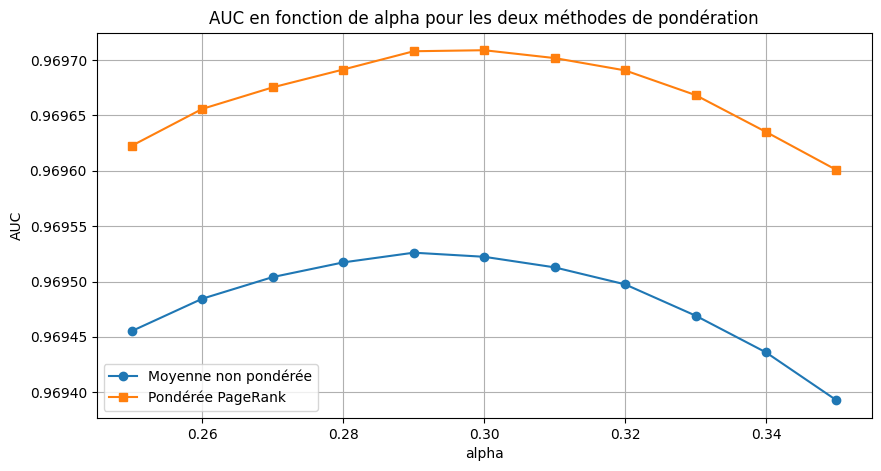

Meilleur alpha (moyenne non pondérée) : 0.29  → AUC = 0.9695
Meilleur alpha (pondérée PageRank)     : 0.30  → AUC = 0.9697


In [52]:
import numpy as np
import matplotlib.pyplot as plt

# valeurs d'alpha à tester
alpha_values = np.linspace(0.25, 0.35, 11)  #Premier essai entre 0 et 1, on a trouvé alpha = 0.3 donnant le auc max

auc_results_V1 = []
auc_results_V2 = []

for alpha in alpha_values:
    print(f"Test alpha = {alpha:.2f}")

    # embeddings améliorés non pondérés
    enhanced_V1 = compute_graph_enhanced_embeddings(
        G, embeddings, id_to_index, alpha=alpha
    )

    # embeddings améliorés pondérés pagerank
    enhanced_V2 = compute_pagerank_weighted_embeddings(
        G, embeddings, id_to_index, pagerank, alpha=alpha
    )

    metrics_V1 = evaluate_top_k(
        enhanced_V1, K, queries, qrels_valid, id_to_index
    )
    metrics_V2 = evaluate_top_k(
        enhanced_V2, K, queries, qrels_valid, id_to_index
    )

    auc_results_V1.append(metrics_V1["auc"])
    auc_results_V2.append(metrics_V2["auc"])

#Affichage

plt.figure(figsize=(10, 5))
plt.plot(alpha_values, auc_results_V1, marker="o", label="Moyenne non pondérée")
plt.plot(alpha_values, auc_results_V2, marker="s", label="Pondérée PageRank")
plt.xlabel("alpha")
plt.ylabel("AUC")
plt.title("AUC en fonction de alpha pour les deux méthodes de pondération")
plt.grid(True)
plt.legend()
plt.show()

# Pour l'affichage direct des meilleurs alpha :
best_alpha_V1 = alpha_values[np.argmax(auc_results_V1)]
best_auc_V1 = max(auc_results_V1)

best_alpha_V2 = alpha_values[np.argmax(auc_results_V2)]
best_auc_V2 = max(auc_results_V2)

print(f"Meilleur alpha (moyenne non pondérée) : {best_alpha_V1:.2f}  → AUC = {best_auc_V1:.4f}")
print(f"Meilleur alpha (pondérée PageRank)     : {best_alpha_V2:.2f}  → AUC = {best_auc_V2:.4f}")


# Création du fichier de submission

Maintenant que l'on a testé une approche creuse, dense et une autre qui utilise l'information de structure, et en ayant trouvé les meilleurs paramètres pour cette dernière, on cherche désormais à appliquer cet algorithme sur le fichier test_final.tsv dont les prédictions ne sont pas connues à l'avance.

In [65]:
import csv
import numpy as np

def load_test_file(path):
    pairs = []
    with open(path, "r", encoding="utf-8") as f:
        next(f)  # skip header
        for line in f:
            qid, cid, _ = line.strip().split("\t")
            pairs.append((qid, cid))
    return pairs

test_pairs = load_test_file("dataset_BE2/test_final.tsv")
print(f"{len(test_pairs)} paires chargées depuis test_final.tsv")

pagerank = nx.pagerank(G, alpha=0.66)

enhanced_embeddings = compute_pagerank_weighted_embeddings(
    G,
    embeddings,
    id_to_index,
    pagerank,
    alpha=0.295      # meilleur alpha
)

# fonction utilitaire pour récupérer l'embedding
def get_emb(doc_id):
    idx = id_to_index.get(doc_id, None)
    if idx is None:
        return None
    return enhanced_embeddings[idx]

def cosine_similarity(a, b):
    if a is None or b is None:
        return 0.0
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return np.dot(a, b) / (na * nb)

output_path = "submission.csv"
row_id = 1

with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["RowId", "query-id", "corpus-id", "score"])

    for qid, cid in test_pairs:
        query_emb = get_emb(qid)
        doc_emb = get_emb(cid)
        score = cosine_similarity(query_emb, doc_emb)

        writer.writerow([row_id, qid, cid, score])
        row_id += 1

print(f"Fichier généré : {output_path}")


8978 paires chargées depuis test_final.tsv


NetworkXError: The node 7b901e88e8a4afcc4c60c52833820156525f4aed is not in the digraph.